In [22]:
import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

import os.path as osp

In [23]:
from utils import load_col_min_max, inverse_min_max_scaler

In [24]:
dataset_name = 'Recidivism'
is_regression = dataset_name in ['Housing', 'Fico']
data =  data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data
col_min_max = load_col_min_max(dataset_name)

In [26]:
from sklearn.model_selection import KFold, StratifiedKFold

NUM_FOLDS = 5
fold_test_indices = []
fold_train_indices = []

if is_regression:
    kfold = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
else:
    kfold = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

all_splits = list(kfold.split(data_x, data_y))

for fold_num in range(1, NUM_FOLDS + 1):
    # Get the indices for this fold (matching get_train_test_fold logic)
    train_idx, test_idx = all_splits[fold_num - 1]
    fold_train_indices.append(train_idx)
    fold_test_indices.append(test_idx)
    
print(f"Fold test set sizes: {[len(idx) for idx in fold_test_indices]}")
print(f"Total test samples: {sum(len(idx) for idx in fold_test_indices)}")
print(f"Total dataset size: {len(data_x)}")
print(f"Test set percentage: {100*sum(len(idx) for idx in fold_test_indices)/len(data_x):.1f}%")


Fold test set sizes: [1235, 1235, 1234, 1234, 1234]
Total test samples: 6172
Total dataset size: 6172
Test set percentage: 100.0%


In [27]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)


In [28]:
import numpy as np
from utils import load_nam_checkpoint
from utils import get_test_predictions, compute_mean_predictions, get_feature_predictions

all_preds_per_fold = [[] for _ in range(5)]
all_hist_data = []
all_mean_pred = []

for fold in range(1, 6):             # 5 folds
    fold_idx = fold - 1
    test_indices = fold_test_indices[fold_idx]
    print(f"Processing fold {fold} (test set size: {len(test_indices)})...")
    
    for split in range(1, 4):       # 3 splits per fold
        if split % 5 == 0:
            print(f"  Processing split {split}...")
        ckpt_dir = f"./compas_default/fold_{fold}/split_{split}/model_0/best_checkpoint"

        nam, sess = load_nam_checkpoint(ckpt_dir,hyperparameters= [])
        
        # Get predictions on the FULL dataset (needed for feature importance plots)
        preds_full = get_test_predictions(nam, data_x.astype(np.float32), sess)
        
        # Store only test set predictions for AUC calculation
        preds_test = preds_full[test_indices]
        all_preds_per_fold[fold_idx].append(preds_test)

        # For feature importance plots, we still need full dataset
        feature_predictions = get_feature_predictions(nam, dataset_name, sess)
        avg_hist_data, mean_pred, _ = compute_mean_predictions(
            data_x, column_names, UNIQUE_FEATURES, feature_predictions
        )

        all_hist_data.append(avg_hist_data)
        all_mean_pred.append(mean_pred)


Processing fold 1 (test set size: 1235)...
Using checkpoint oyee: ./compas_default/fold_1/split_1/model_0/best_checkpoint\model.ckpt-560
Feature widths: [124, 4, 12, 4, 66, 402]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas_default/fold_1/split_1/model_0/best_checkpoint\model.ckpt-560
✅ Restored NAM from checkpoint.
Using checkpoint oyee: ./compas_default/fold_1/split_2/model_0/best_checkpoint\model.ckpt-400
Feature widths: [128, 4, 12, 4, 66, 392]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas_default/fold_1/split_2/model_0/best_checkpoint\model.ckpt-400
✅ Restored NAM from checkpoint.
Using checkpoint oyee: ./compas_default/fold_1/split_3/model_0/best_checkpoint\model.ckpt-480
Feature widths: [126, 4, 12, 4, 68, 406]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas_default/fold_1/split_3/model_0/best_checkpoint\model.ckpt-480
✅ Restored NAM from checkpoint.
Processing fold 2 (test set size: 1235)...
Using ch

In [ ]:
import os
import glob
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

ckpt_dir = r"./compas_default/fold_1/split_1/model_0/best_checkpoint"  # <- change this

# 1) Find the checkpoint prefix (model.ckpt-XXXX)
ckpt_path = tf.train.latest_checkpoint(ckpt_dir)
if ckpt_path is None:
    # Fallback: pick the first .index file
    index_files = glob.glob(os.path.join(ckpt_dir, "*.index"))
    print("latest_checkpoint() returned None")
    print("index files found:", [os.path.basename(f) for f in index_files])
    if not index_files:
        raise FileNotFoundError(f"No .index files found in {ckpt_dir}")
    ckpt_path = os.path.splitext(index_files[0])[0]

print("Using checkpoint:", ckpt_path)

# 2) Read variables from the checkpoint
reader = tf.train.NewCheckpointReader(ckpt_path)
var_map = reader.get_variable_to_shape_map()
print("Number of variables:", len(var_map))

# 3) Print first 50 variable names + shapes
for i, (name, shape) in enumerate(sorted(var_map.items())):
    print(f"{i:3d}: {name:60} {shape}")
    if i >= 49:  # stop after 50
        break


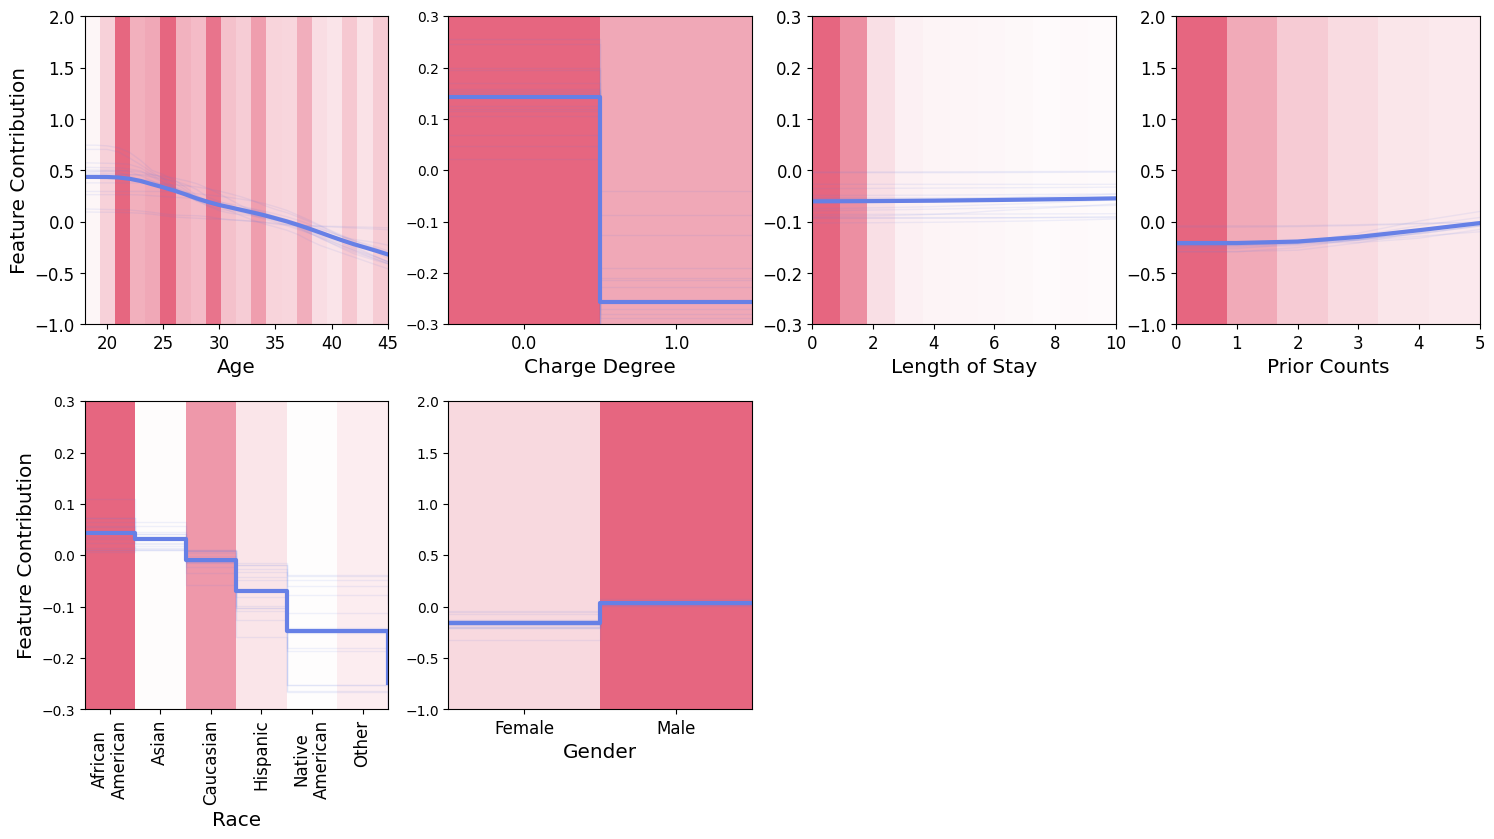

In [29]:
from utils import plot_nam_contributions_with_density

x_limits = {
    'age': 45,
    'length_of_stay': 10,
    'priors_count': 5
}

y_limits = {
    'age': (-1, 2),
    'c_charge_degree': (-0.3, 0.3),
    'length_of_stay': (-0.3, 0.3),
    'priors_count': (-1, 2),
    'race': (-0.3, 0.3),
    'sex': (-1, 2)
}

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    x_limits=x_limits,
    y_limits=y_limits
)


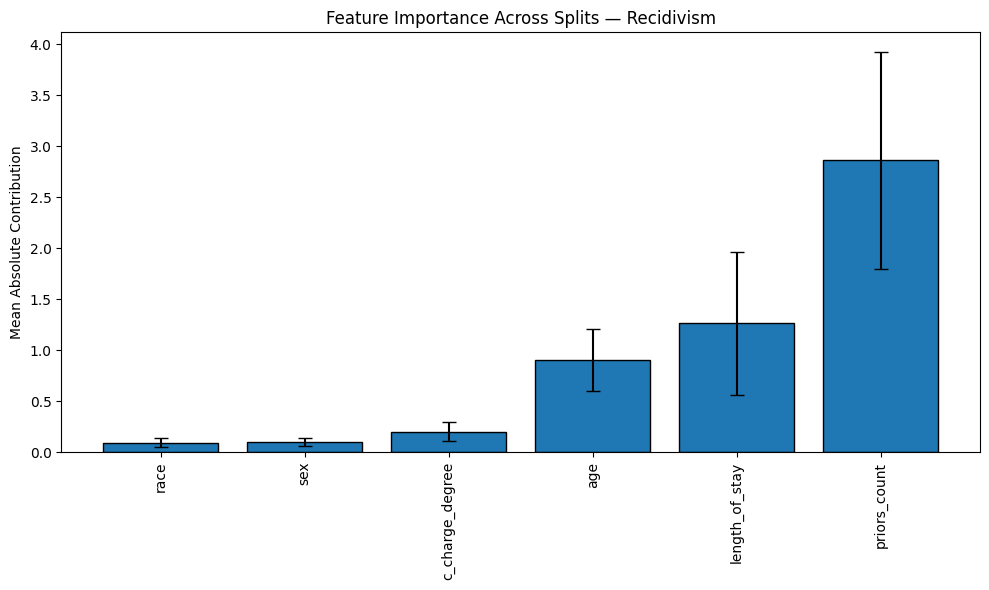

In [30]:
from utils import compute_mean_feature_importance
import numpy as np
import matplotlib.pyplot as plt

# Compute per-split importances
all_feature_importances = []

for avg_hist_data, mean_pred in zip(all_hist_data, all_mean_pred):
    feature_names, importances = compute_mean_feature_importance(avg_hist_data, mean_pred)
    all_feature_importances.append(importances)

# Combine into matrix (splits x features)
all_feature_importances = np.vstack(all_feature_importances)

# Average and std across splits
importance_mean = all_feature_importances.mean(axis=0)
importance_std  = all_feature_importances.std(axis=0)

# Sort features by mean importance
sorted_idx = np.argsort(importance_mean)
sorted_features = np.array(feature_names)[sorted_idx]
sorted_mean = importance_mean[sorted_idx]
sorted_std  = importance_std[sorted_idx]

# Plot averaged feature importance with error bars
plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_mean, yerr=sorted_std, capsize=5, edgecolor="k")
plt.xticks(rotation=90)
plt.ylabel("Mean Absolute Contribution")
plt.title(f"Feature Importance Across Splits — {dataset_name}")
plt.tight_layout()
plt.show()


In [31]:
fold_aucs = []

for fold_idx in range(5):
    # Get test set indices and labels for this fold
    test_indices = fold_test_indices[fold_idx]
    y_test_fold = data_y[test_indices]
    
    # Ensemble predictions
    preds = np.vstack(all_preds_per_fold[fold_idx])   # (20, n_test_samples)
    ensemble_pred = preds.mean(axis=0)
    
    # Compute AUC only on test set
    auc = graph_builder.calculate_metric(
        y_test_fold,
        ensemble_pred,
        regression=False
    )
    fold_aucs.append(auc)
    print(f"Fold {fold_idx+1} AUC (test set only): {auc:.4f} (n={len(test_indices)})")

fold_aucs = np.array(fold_aucs)
avg_auc = fold_aucs.mean()
std_auc = fold_aucs.std()

print(f"\nAverage Ensemble AUC across folds (test sets only): {avg_auc:.4f}")
print(f"Std of Ensemble AUC across folds: {std_auc:.4f}")


Fold 1 AUC (test set only): 0.7065 (n=1235)
Fold 2 AUC (test set only): 0.7042 (n=1235)
Fold 3 AUC (test set only): 0.7074 (n=1234)
Fold 4 AUC (test set only): 0.6841 (n=1234)
Fold 5 AUC (test set only): 0.7066 (n=1234)

Average Ensemble AUC across folds (test sets only): 0.7018
Std of Ensemble AUC across folds: 0.0089
